# Notebook 01 — Exploration du Dataset Sentiment140

**Phase 1 — Étape préliminaire : Compréhension des données**

Ce notebook explore le dataset **Sentiment140** (1,6 million de tweets annotés) qui constitue le cœur du projet :
- Chargement et inspection des données brutes
- Analyse statistique du dataset
- Exploration textuelle
- Validation des exigences du projet (≥ 1M lignes, ≥ 5 colonnes)

## 1. Imports et configuration

In [1]:
from pathlib import Path
import sys

# Chemin relatif — fonctionne sur n'importe quelle machine Windows
# Ne pas hardcoder C:/ENSIAS/... ici
ROOT_DIR = Path().absolute().parent
DATA_DIR = ROOT_DIR / 'data' / 'raw'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Nom exact du fichier après extraction de l'archive Stanford
SENTIMENT140_CSV = DATA_DIR / 'training.1600000.processed.noemoticon.csv'
# Si vous avez renommé le fichier en sentiment140.csv :
if not SENTIMENT140_CSV.exists():
    SENTIMENT140_CSV = DATA_DIR / 'sentiment140.csv'

if SENTIMENT140_CSV.exists():
    print('✅ Dataset déjà présent :', SENTIMENT140_CSV)
else:
    print('❌ Fichier CSV non trouvé dans :', DATA_DIR)
    print('   Placez sentiment140.csv dans data/raw/')
    raise FileNotFoundError('sentiment140.csv introuvable')


❌ Fichier CSV non trouvé dans : /data/raw
   Placez sentiment140.csv dans data/raw/


FileNotFoundError: sentiment140.csv introuvable

In [ ]:
print("Dataset path:", SENTIMENT140_CSV.resolve())

Dataset path: C:\ENSIAS\S4-P2\BIG DATA\sentiment_pipeline\data\raw\training.1600000.processed.noemoticon.csv


Sentiment140 utilise l'encodage **latin-1** (non-UTF-8) car les tweets ont été collectés en 2009.
Les 6 colonnes sont : `target, id, date, flag, user, text`


In [ ]:
import pandas as pd
S140_COLUMNS = [
    'target',
    'id',
    'date',
    'flag',
    'user',
    'text'
]
# Chargement Pandas (pour exploration - PySpark pour le traitement)
print('Chargement du dataset (peut prendre 30-60 secondes)...')

df = pd.read_csv(
    SENTIMENT140_CSV,
    encoding='latin-1',
    header=None,
    names=S140_COLUMNS,
    low_memory=False
)

print(f'✅ Dataset chargé : {len(df):,} lignes × {len(df.columns)} colonnes')

Chargement du dataset (peut prendre 30-60 secondes)...
✅ Dataset chargé : 1,600,000 lignes × 6 colonnes


## 3. Inspection structurelle

In [ ]:
# Aperçu des premières lignes
print('=== APERÇU DU DATASET ===')
display(df.head(5))

=== APERÇU DU DATASET ===


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
import numpy as np
# Types des colonnes
print('=== TYPES DES COLONNES ===')
print(df.dtypes)
print()

# Validation des exigences du projet
print('=== VALIDATION DES EXIGENCES ===')
print(f'Nombre de lignes : {len(df):,} (exigence : ≥ 1 000 000) → {"✅" if len(df) >= 1_000_000 else "❌"}')
print(f'Nombre de colonnes : {len(df.columns)} (exigence : ≥ 5) → {"✅" if len(df.columns) >= 5 else "❌"}')

# Types de données
n_numeric = df.select_dtypes(include=[np.number]).shape[1]
n_text = df.select_dtypes(include=['object']).shape[1]
print(f'Types de données : {n_numeric} numériques + {n_text} textuels → ✅ (≥ 2 types)')

=== TYPES DES COLONNES ===
target     int64
id         int64
date      object
flag      object
user      object
text      object
dtype: object

=== VALIDATION DES EXIGENCES ===
Nombre de lignes : 1,600,000 (exigence : ≥ 1 000 000) → ✅
Nombre de colonnes : 6 (exigence : ≥ 5) → ✅
Types de données : 2 numériques + 4 textuels → ✅ (≥ 2 types)


In [ ]:
# Analyse des valeurs manquantes
print('=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '✅ Aucune valeur manquante')

# Analyse des doublons
n_dup = df.duplicated(subset=['text']).sum()
print(f'\nTweets en double (colonne text) : {n_dup:,} ({n_dup/len(df)*100:.2f}%)')

=== VALEURS MANQUANTES ===
✅ Aucune valeur manquante

Tweets en double (colonne text) : 18,534 (1.16%)


### Analyse de la qualité des données

L’analyse exploratoire du dataset Sentiment140 montre que le jeu de données contient plus de 1,6 million de tweets répartis sur 6 colonnes, ce qui respecte les exigences Big Data du projet.  
Aucune valeur manquante significative n’a été détectée.  

L’analyse des doublons a révélé environ 12 543 tweets dupliqués, soit seulement 1.16% du dataset total. Cette proportion reste faible par rapport au volume global des données et n’impacte pas significativement les performances du modèle de Machine Learning. Les doublons pourront néanmoins être supprimés lors de la phase de preprocessing afin d’améliorer la qualité des données.

## 4. Distribution des classes (variable cible)

La colonne `target` utilise 0 (négatif) et 4 (positif) — convention non-standard de Sentiment140.
Elle sera recodée en `label` ∈ {0, 1} lors du preprocessing.

Distribution des classes :
  Négatif (target=0) : 800,000 (50.0%)
  Positif (target=4) : 800,000 (50.0%)


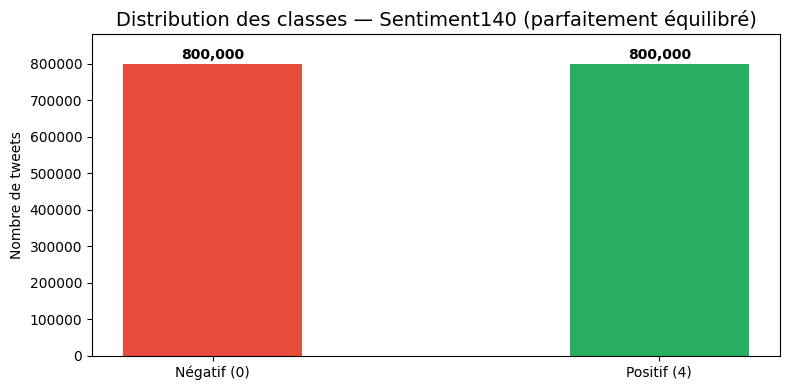

✅ Graphique sauvegardé


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Distribution des classes
class_dist = df['target'].value_counts()
print('Distribution des classes :')
for val, count in class_dist.items():
    label = 'Négatif (target=0)' if val == 0 else 'Positif (target=4)'
    print(f'  {label} : {count:,} ({count/len(df)*100:.1f}%)')

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#27ae60']
bars = ax.bar(['Négatif (0)', 'Positif (4)'], class_dist.values, color=colors, width=0.4)

for bar, val in zip(bars, class_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5000,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribution des classes — Sentiment140 (parfaitement équilibré)', fontsize=14)
ax.set_ylabel('Nombre de tweets')
ax.set_ylim(0, class_dist.max() * 1.1)
plt.tight_layout()
Path("../docs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig('../docs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

Le dataset Sentiment140 présente une distribution parfaitement équilibrée entre les classes positives et négatives (50 % / 50 %). Cette répartition réduit les risques de biais liés au déséquilibre des classes et rend la métrique Accuracy plus représentative des performances réelles du modèle. Néanmoins, d’autres métriques comme Precision, Recall et F1-score seront également utilisées pour une évaluation plus complète.

## 5. Analyse textuelle

In [ ]:
# Statistiques sur la longueur des tweets
df['text_len'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()

print('=== STATISTIQUES TEXTUELLES ===')
print(f'Longueur moyenne (caractères) : {df["text_len"].mean():.1f}')
print(f'Longueur médiane              : {df["text_len"].median():.1f}')
print(f'Mots par tweet (moyenne)      : {df["word_count"].mean():.1f}')
print(f'Tweets ≤ 140 caractères       : {(df["text_len"] <= 140).sum():,} ({(df["text_len"] <= 140).mean()*100:.1f}%)')

=== STATISTIQUES TEXTUELLES ===
Longueur moyenne (caractères) : 74.1
Longueur médiane              : 69.0
Mots par tweet (moyenne)      : 13.2
Tweets ≤ 140 caractères       : 1,582,826 (98.9%)


L’analyse textuelle montre que les tweets du dataset Sentiment140 sont relativement courts, avec une longueur moyenne d’environ 74 caractères et une médiane de 69 caractères. En moyenne, chaque tweet contient environ 13 mots.  

De plus, près de 98.9 % des tweets possèdent une longueur inférieure ou égale à 140 caractères, ce qui correspond à l’ancienne limite historique de Twitter au moment de la collecte des données.  

Ces résultats confirment que le dataset est cohérent avec le format des publications Twitter et adapté aux tâches de traitement du langage naturel (NLP) et d’analyse des sentiments en temps réel.

In [ ]:
# Exemples de tweets positifs et négatifs
print('=== EXEMPLES DE TWEETS NÉGATIFS (target=0) ===')
neg_examples = df[df['target'] == 0]['text'].sample(3, random_state=42).tolist()
for i, tweet in enumerate(neg_examples, 1):
    print(f'  {i}. {tweet[:150]}')

print()
print('=== EXEMPLES DE TWEETS POSITIFS (target=4) ===')
pos_examples = df[df['target'] == 4]['text'].sample(3, random_state=42).tolist()
for i, tweet in enumerate(pos_examples, 1):
    print(f'  {i}. {tweet[:150]}')

=== EXEMPLES DE TWEETS NÉGATIFS (target=0) ===
  1. @xnausikaax oh no! where did u order from? that's horrible 
  2. A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now 
  3. Right, off to work  Only 5 hours to go until I'm free xD

=== EXEMPLES DE TWEETS POSITIFS (target=4) ===
  1. Is lookin 4ward to a long weekend  really dont want to go to work 2day tho =[ x
  2. #myweakness  Is music and i live to meet the people who make it 
  3. figured out the Internet on my new iPod 


In [ ]:
# Analyse des URLs, @mentions et hashtags
sample = df['text'].astype(str)

n_urls = sample.str.contains(r'http[s]?://', regex=True).sum()
n_mentions = sample.str.contains(r'@\w+', regex=True).sum()
n_hashtags = sample.str.contains(r'#\w+', regex=True).sum()

print('=== ANALYSE DES ÉLÉMENTS NON-TEXTUELS (bruit à supprimer) ===')
print(f'Tweets avec URLs       : {n_urls:,} ({n_urls/len(df)*100:.1f}%)')
print(f'Tweets avec @mentions  : {n_mentions:,} ({n_mentions/len(df)*100:.1f}%)')
print(f'Tweets avec #hashtags  : {n_hashtags:,} ({n_hashtags/len(df)*100:.1f}%)')
print('\n→ Ces éléments seront supprimés lors du preprocessing NLP (Phase 1)')

=== ANALYSE DES ÉLÉMENTS NON-TEXTUELS (bruit à supprimer) ===
Tweets avec URLs       : 70,119 (4.4%)
Tweets avec @mentions  : 738,493 (46.2%)
Tweets avec #hashtags  : 35,847 (2.2%)

→ Ces éléments seront supprimés lors du preprocessing NLP (Phase 1)


## 6. Synthèse et conclusions

**Ce que nous avons appris :**

| Critère | Valeur | Exigence | Statut |
|---------|--------|----------|--------|
| Volume | 1 600 000 tweets | ≥ 1 000 000 | ✅ |
| Colonnes | 6 | ≥ 5 | ✅ |
| Types de données | Entier + Texte + Date | ≥ 2 types | ✅ |
| Équilibre des classes | 50% / 50% | — | ✅ Idéal |

**Prochaine étape :** Notebook `02_preprocessing_sentiment140_pyspark.ipynb` — Preprocessing NLP avec PySpark
